# Global sensitivity analysis & scenario discovery

This notebook is the runnable companion of the step-by-step tutorial
([HTML version](../docs/tutorial-gsa-and-scenario-discovery.html)). It adds two standard
uncertainty-analysis tools on top of the workflow shown in the
[Insulation tutorial](Insulation.ipynb), using the same SEVEN-project peak-energy model.

- **Global sensitivity analysis (GSA)** — *which uncertain parameters drive the variance
  of the outcome?* Variance-based Sobol indices (first-order `S1` and total-order `ST`).
  This differs from intervention ranking (which ranks *levers*) and from one-factor-at-a-
  time analysis (GSA captures interactions).
- **Scenario discovery** — *which combinations of uncertain inputs lead to a bad outcome?*
  PRIM/CART find interpretable regions (boxes/rules) of the input space where cases of
  concern concentrate, reported with **density** (precision) and **coverage** (recall).

Together: GSA tells you *which assumptions your conclusion is most sensitive to*; scenario
discovery tells you *which combinations of conditions produce the bad outcome*.

In [1]:
from sip_systemsinsightpipeline import Extract, SDM, discover_scenarios
from sip_systemsinsightpipeline.plots import plot_gsa, plot_scenario_tradeoff, plot_scenario_box

s = Extract('Insulation_PeakEnergy.xlsx').extract_settings()
s.seed = 0
s.N = 1
s.t_end = 15
s.time_unit = 'years'
s.parameter_value_aux = 0.3
s.parameter_value_stocks = 0.1
sdm = SDM(s)
voi = s.variable_of_interest[0]
print('free uncertain parameters:', len(sdm._gsa_parameter_spec()[0]))

Variable of interest: Percentage of electricity use during peak hours (16.00-21.00) on household level
with 51 intervention variables

21 feedback loops of maximum length 5
All loops have at least one stock
No interaction terms specified so will solve linear SDM.
free uncertain parameters: 94


## 1. Global sensitivity analysis

`run_GSA` draws a Saltelli/Sobol design over the model's uncertain parameters (the same
uniform priors `run_simulations` samples from), evaluates the model once per design point
under a chosen intervention scenario (here the default: every intervention applied at unit
intensity), reduces each run to the outcome, and estimates Sobol indices.

Total runs = `n * (d + 2)`, so keep `n` modest for a first look on a large model.

In [2]:
# n is small here so the notebook runs quickly; raise it (e.g. 512+) for tighter CIs.
gsa_df = sdm.run_GSA(voi, n=64, seed=1)
gsa_df.head(12)

GSA: evaluating Sobol design:   0%|          | 0/6144 [00:00<?, ?it/s]

GSA: evaluating Sobol design:   0%|          | 11/6144 [00:00<00:57, 106.21it/s]

GSA: evaluating Sobol design:   0%|          | 22/6144 [00:00<00:58, 104.71it/s]

GSA: evaluating Sobol design:   1%|          | 33/6144 [00:00<00:58, 105.11it/s]

GSA: evaluating Sobol design:   1%|          | 44/6144 [00:00<00:57, 106.23it/s]

...

GSA: evaluating Sobol design:  99%|█████████▉| 6112/6144 [00:53<00:00, 115.53it/s]

GSA: evaluating Sobol design: 100%|█████████▉| 6124/6144 [00:53<00:00, 114.35it/s]

GSA: evaluating Sobol design: 100%|█████████▉| 6136/6144 [00:53<00:00, 114.30it/s]

GSA: evaluating Sobol design: 100%|██████████| 6144/6144 [00:53<00:00, 113.93it/s]

,parameter,S1,S1_low,S1_high,S1_conf,ST,ST_low,ST_high,ST_conf
0,Percentage of electricity use during peak hour...,0.444891,0.224490,0.711185,0.243348,0.422221,0.279354,0.631835,0.176241
1,Percentage of electricity use during peak hour...,0.304630,0.154507,0.457191,0.151342,0.222942,0.151822,0.326552,0.087365
2,Percentage of electricity use during peak hour...,0.026888,0.000000,0.114091,0.057046,0.056406,0.036976,0.087673,0.025348
3,Percentage of electricity use during peak hour...,0.118350,0.041912,0.209770,0.083929,0.053382,0.033496,0.078923,0.022714
4,Percentage of electricity that is smart-contro...,0.000000,0.000000,0.000000,0.000000,0.031851,0.018650,0.046384,0.013867
5,Preceived cost savings <- Percentage of electr...,0.014708,0.000000,0.068160,0.034080,0.027763,0.015998,0.045667,0.014835
6,Degree of controllability of electricity use (...,0.057694,0.000000,0.128918,0.064459,0.022670,0.014031,0.034460,0.010215
7,Willingness to adopt flexible electricity usag...,0.018643,0.000000,0.062313,0.031156,0.010561,0.005621,0.017720,0.006050
8,Percentage of electricity that is smart-contro...,0.064131,0.030830,0.101060,0.035115,0.008964,0.004586,0.015086,0.005250
9,Willingness to adopt flexible electricity usag...,0.000000,0.000000,0.033802,0.016901,0.008263,0.005396,0.011921,0.003262


C:\Users\vvvas\OneDrive - UvA\Office\Research Projects\SIP - Systems Insight Pipeline\SystemsInsightPipeline\sip_systemsinsightpipeline\plots.py:205: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


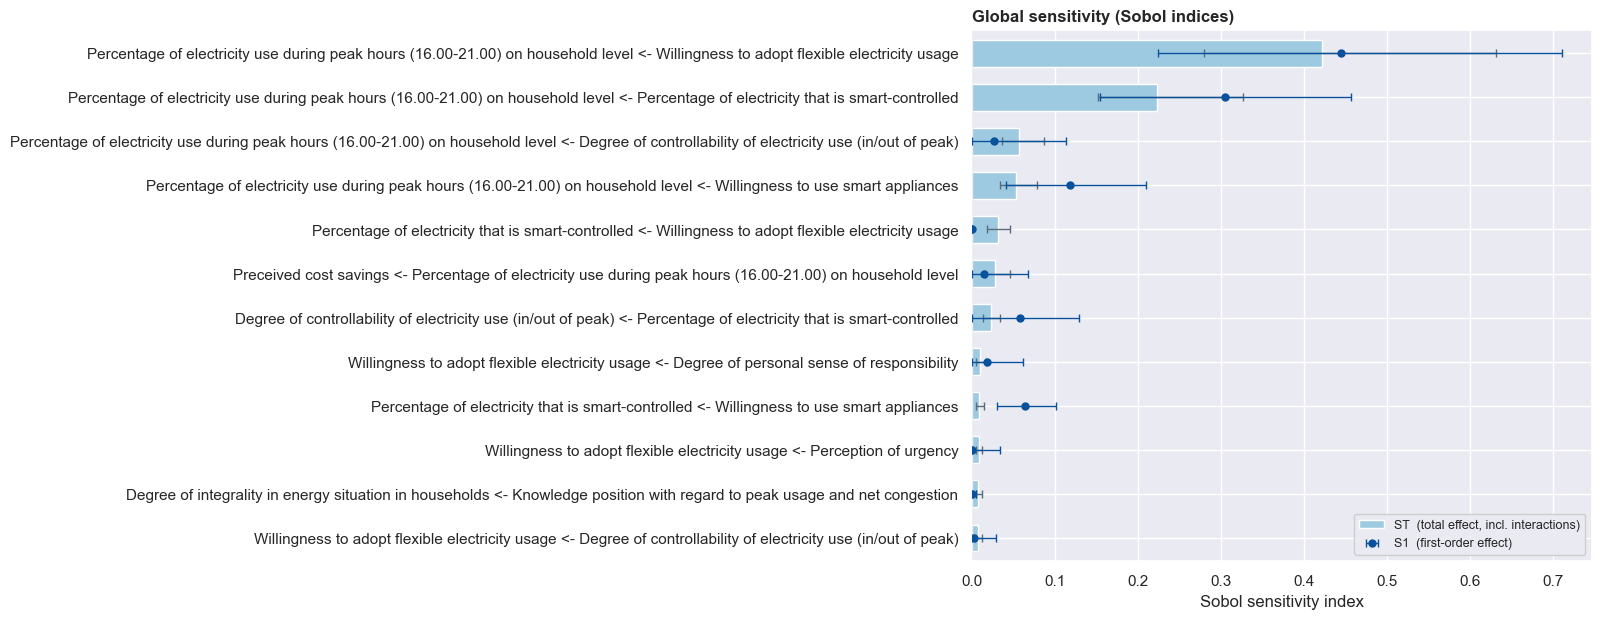

In [3]:
# Sobol tornado: total-order ST (bars) with first-order S1 (markers) and CI whiskers.
fig = plot_gsa(gsa_df, top=12)

**How to read it.** `ST` (total-order) is the share of outcome variance a parameter drives
*including* its interactions with others; `S1` (first-order) is its effect alone. A large
`ST` with small `S1` means the parameter matters mostly *through interactions*. Parameters
at the top are where better evidence would most reduce the uncertainty in your conclusions.
Wide confidence whiskers mean `n` is too small — increase it.

Sobol indices live in `[0, 1]`, but their estimator (a difference of variances) can dip
slightly negative for an unimportant parameter at finite `n`. `run_GSA` therefore projects
the estimate and its confidence interval onto `[0, 1]` by default (`clip=True`), so such a
parameter reports `S1 = 0` with a one-sided interval like `[0, 0.05]` ('indistinguishable
from zero'). The interval columns `S1_low`/`S1_high` (and `ST_low`/`ST_high`) are an
*asymmetric* percentile bootstrap, which is the right shape near the 0/1 boundary; pass
`clip=False` for the raw estimates as a convergence diagnostic.

## 2. Scenario discovery

`sample_outcomes` draws an independent ensemble of parameter sets and their outcomes;
`discover_scenarios` then localises the region of input space where the *cases of concern*
concentrate. Here the concern is that peak-hour electricity use stays **high** (least
reduced) despite the full intervention package.

In [4]:
X, y = sdm.sample_outcomes(n=1500, seed=2)
import numpy as np
threshold = float(np.quantile(y, 0.8))   # worst 20% of outcomes = 'high peak use'

result = discover_scenarios(X, y, threshold=threshold, direction='above',
                            method='prim', peel_alpha=0.05, min_coverage=0.5)
box = result.box
print('density (precision):', round(box.density, 3))
print('coverage (recall)  :', round(box.coverage, 3))
print('mass               :', round(box.mass, 3))
box.limits

GSA: evaluating Sobol design:   0%|          | 0/1500 [00:00<?, ?it/s]

GSA: evaluating Sobol design:   1%|          | 12/1500 [00:00<00:13, 113.61it/s]

GSA: evaluating Sobol design:   2%|▏         | 24/1500 [00:00<00:12, 117.27it/s]

GSA: evaluating Sobol design:   2%|▏         | 36/1500 [00:00<00:12, 115.32it/s]

GSA: evaluating Sobol design:   3%|▎         | 48/1500 [00:00<00:12, 113.58it/s]

...

GSA: evaluating Sobol design:  99%|█████████▉| 1487/1500 [00:13<00:00, 111.32it/s]

GSA: evaluating Sobol design: 100%|█████████▉| 1499/1500 [00:13<00:00, 110.78it/s]

GSA: evaluating Sobol design: 100%|██████████| 1500/1500 [00:13<00:00, 110.70it/s]

density (precision): 0.837
coverage (recall)  : 0.513
mass               : 0.123


,min,max
dimension,,
Percentage of electricity that is smart-controlled <- Willingness to adopt flexible electricity usage,0.000124,0.094441
Percentage of electricity that is smart-controlled <- Policy agreement for smart appliances,0.006350,0.099966
Degree of controllability of electricity use (in/out of peak) <- Degree of HEMS usage,0.000067,0.094930
Knowledge position with regard to peak usage and net congestion <- Comprehensibility of tariff structures,0.000021,0.096808
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Percentage of electricity that is smart-controlled,-0.056544,-0.000170
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of controllability of electricity use (in/out of peak),-0.094437,-0.000051
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Preceived cost savings,-0.094272,-0.000004
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to adopt flexible electricity usage,-0.031434,-0.000085
Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to use smart appliances,-0.095212,-0.000191


**How to read it.** PRIM *peels* the input box to raise **density** (the share of points
inside that are cases of concern) while watching **coverage** (the share of all concerning
cases still captured). `box.limits` lists only the dimensions PRIM actually had to restrict
— the parameters whose values jointly produce the bad outcome; everything else is left
unconstrained, which is itself the finding.

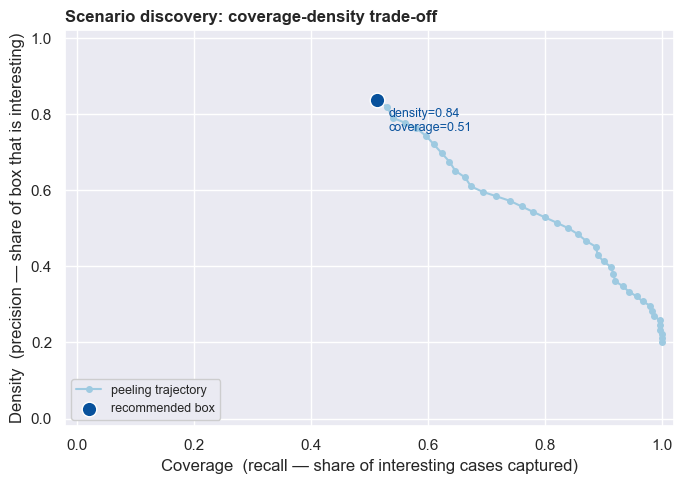

In [5]:
fig = plot_scenario_tradeoff(result)

The peeling curve shows the coverage-density trade-off: each step sacrifices some coverage
to gain density. The highlighted point is the recommended box; pick a different point if you
prefer broader coverage over tighter precision.

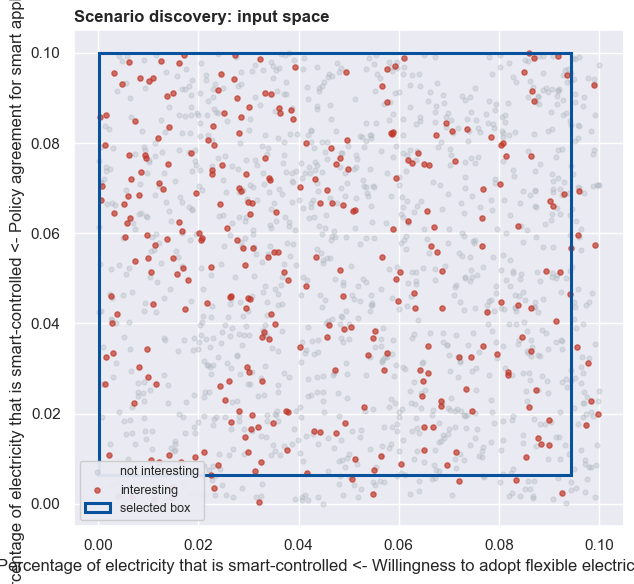

In [6]:
# Scatter the two most-restricted inputs, coloured by concern, with the box drawn.
rdims = box.restricted_dimensions
if len(rdims) >= 2:
    fig = plot_scenario_box(result, rdims[0], rdims[1], X)
else:
    print('Only one dimension was restricted:', rdims)

## 3. CART: the same question as a decision tree

CART is an alternative that recovers axis-aligned rules; it is good for cross-checking which
variables matter (the splitting variables) and for non-box-shaped regions.

In [7]:
res_cart = discover_scenarios(X, y, threshold=threshold, direction='above',
                              method='cart', max_depth=3, min_density=0.7, seed=0)
print('splitting variables:', res_cart.splitting_variables)
for rule in res_cart.rules[:3]:
    print(' -', rule)

splitting variables: ['Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of controllability of electricity use (in/out of peak)', 'Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of integrality in energy situation in households', 'Percentage of electricity use during peak hours (16.00-21.00) on household level <- Percentage of electricity that is smart-controlled', 'Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to adopt flexible electricity usage']
 - Percentage of electricity use during peak hours (16.00-21.00) on household level <- Willingness to adopt flexible electricity usage > -0.03112 and Percentage of electricity use during peak hours (16.00-21.00) on household level <- Percentage of electricity that is smart-controlled > -0.05179 and Percentage of electricity use during peak hours (16.00-21.00) on household level <- Degree of controllability of 

## References

- Saltelli, A. et al. (2008). *Global Sensitivity Analysis: The Primer.* Wiley.
- Sobol', I. M. (2001). Global sensitivity indices for nonlinear mathematical models and
  their Monte Carlo estimates. *Mathematics and Computers in Simulation*, 55(1-3).
- Friedman, J. H. & Fisher, N. I. (1999). Bump hunting in high-dimensional data.
  *Statistics and Computing*, 9(2).
- Kwakkel, J. H. & Jaxa-Rozen, M. (2016). Improving scenario discovery for handling
  heterogeneous uncertainties. *Environmental Modelling & Software*, 79.
- Herman, J. & Usher, W. (2017). SALib: An open-source Python library for sensitivity
  analysis. *Journal of Open Source Software*, 2(9).